# Spectral Earth Dataset Wrapper Test

In [3]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

Adding /home/ando to sys.path


In [4]:
from src.datasets.spectral_earth_wrapper import SpectralEarthDataset
from src.factory import create_dataset

dataset = SpectralEarthDataset(root='/data/panopticon/datasets/spectral_earth', split='train', task_dir='corine')

# sample = dataset[0]



/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO:dinov2:SE Labels dir: /data/panopticon/datasets/spectral_earth/spectral_earth_downstream_datasets/enmap_corine/corine


In [7]:
sample, label = dataset[0]
sample.shape, label

(torch.Size([202, 128, 128]),
 tensor([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]))

In [27]:
from omegaconf import OmegaConf
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('src/configs/dataset/corine_21.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

config: {'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 21, 'band_ids': [0, 15, 23, 30, 39, 52, 54, 69, 73, 81, 94, 107, 114, 123, 132, 142, 148, 154, 169, 175, 191], 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 224, 'multilabel': True, 'full_spectra': True}


In [28]:
display(ds_cfg)

{'defaults': ['base_dataset'], 'dataset_type': 'corine', 'task': 'classification', 'dataset_name': 'spectral_earth', 'num_classes': 19, 'num_channels': 21, 'band_ids': [0, 15, 23, 30, 39, 52, 54, 69, 73, 81, 94, 107, 114, 123, 132, 142, 148, 154, 169, 175, 191], 'data_path': '${oc.env:DATASETS_DIR}/spectral_earth', 'image_resolution': 224, 'multilabel': True, 'full_spectra': True, 'wavelengths_mean_nm': [418, 491, 530, 566, 616, 699, 713, 824, 855, 911, 968, 1070, 1151, 1258, 1597, 1706, 2005, 2059, 2191, 2241, 2369], 'wavelengths_sigma_nm': [2, 2, 2, 2, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3]}

In [29]:
sample, label = train_ds[11]
sample.shape, label

(torch.Size([21, 224, 224]),
 tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]))

In [31]:
sample, label = val_ds[11]
sample.shape, label

(torch.Size([21, 224, 224]),
 tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]))

In [30]:
sample, label = test_ds[-1]
sample.shape, label

(torch.Size([21, 224, 224]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]))

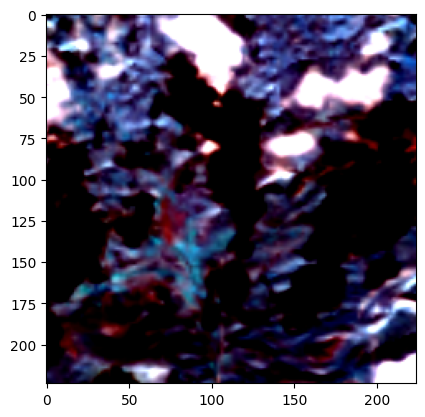

In [36]:
rgb = sample[0,[5,8,10], :, :]


import matplotlib.pyplot as plt

img = rgb.permute(1, 2, 0).numpy()

img = img - img.min() / (img.max() - img.min())

plt.imshow(img)
plt.show()



## Test Channel Sampler